# **# Customer Lifetime Value Prediction Model**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orders = pd.read_csv("1) a) olist_orders_dataset.csv")
items = pd.read_csv("1) b) olist_order_items_dataset.csv")
payments  = pd.read_csv("1) c) olist_order_payments_dataset.csv")
customers  = pd.read_csv("1) d) olist_customers_dataset.csv")

orders.shape
#items.shape
#payments.shape
#customers.shape

(99441, 8)

In [3]:
orders.head()
#items.head()
#payments.head()
#customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
orders.info()   # Yes there are Null Values 
items.info()     # No Null Values
payments.info()   # No Null Values
customers.info()   # No Null Values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 

In [5]:
orders.info()
orders["order_status"].value_counts()  # Catgeorization by order status
orders["customer_id"].nunique()  # No. of unique customers

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


99441

In [6]:
items.info()
print("Unique orders: ", items['order_id'].nunique())  # No. of unique orders
print("Unique orders: ", items['product_id'].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
Unique orders:  98666
Unique orders:  32951


In [7]:
payments.info()
print("payment_types:", payments["payment_type"].value_counts())
total_revenue = payments["payment_value"].sum()
print(f"Total revenue = {total_revenue}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB
payment_types: payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64
Total revenue = 16008872.12


In [8]:
customers.info()
print(f"No. of unique customers: {customers["customer_unique_id"].nunique()}") 
print(f"Statewise Categorization of customers: {customers["customer_state"].value_counts()}") 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
No. of unique customers: 96096
Statewise Categorization of customers: customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64


In [9]:
# Merging orders with payments
op = orders.merge(payments, on="order_id", how = "inner")
op = op[op["order_status"] =="delivered" ]  # Only delivered/fully completed orders matter in CLV prediction.
revenue_map = payments.groupby("order_id")["payment_value"].sum()
op["order_revenue"] = op["order_id"].map(revenue_map)
op.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,order_revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,1,18.12,38.71
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,1,2.00,38.71
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,1,18.59,38.71
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,1,141.46,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,3,179.12,179.12


In [10]:
# Aggregate to Customer level
customer_df = op.groupby("customer_id").agg(
    frequency = ('order_id', 'nunique'),
    monetary = ('order_revenue', 'sum'),
    first_purchase = ('order_purchase_timestamp', 'min'),
    last_purchase = ('order_purchase_timestamp', 'max')
).reset_index()

# Changing timestamps to datetime
customer_df['first_purchase'] = pd.to_datetime(customer_df['first_purchase'])
customer_df['last_purchase'] = pd.to_datetime(customer_df['last_purchase'])

customer_df.head()

,customer_id,frequency,monetary,first_purchase,last_purchase
0,00012a2ce6f8dcda20d059ce98491703,1,114.74,2017-11-14 16:08:26,2017-11-14 16:08:26
1,000161a058600d5901f007fab4c27140,1,67.41,2017-07-16 09:40:32,2017-07-16 09:40:32
2,0001fd6190edaaf884bcaf3d49edf079,1,195.42,2017-02-28 11:06:43,2017-02-28 11:06:43
3,0002414f95344307404f0ace7a26f1d5,1,179.35,2017-08-16 13:09:20,2017-08-16 13:09:20
4,000379cdec625522490c315e70c7a9fb,1,107.01,2018-04-02 13:42:17,2018-04-02 13:42:17


In [11]:
# Create RFM Features
# recency= days since last purchase (assuming snapshot is last date in the dataset)
snapshot_date = customer_df["last_purchase"].max() + pd.Timedelta(days=1)
customer_df["recency"] = (snapshot_date - customer_df["last_purchase"]).dt.days

# tenure = days between first and last purchase
customer_df["tenure"] = (customer_df['last_purchase'] - customer_df['first_purchase']).dt.days

# Avg Order Value
customer_df["avg_order_value"] = customer_df["monetary"]/customer_df["frequency"]

# State wise Categorization
customer_df = customer_df.merge(customers[["customer_id", "customer_state"]], on="customer_id", how = "left")

customer_df.head()

,customer_id,frequency,monetary,first_purchase,last_purchase,recency,tenure,avg_order_value,customer_state
0,00012a2ce6f8dcda20d059ce98491703,1,114.74,2017-11-14 16:08:26,2017-11-14 16:08:26,288,0,114.74,SP
1,000161a058600d5901f007fab4c27140,1,67.41,2017-07-16 09:40:32,2017-07-16 09:40:32,410,0,67.41,MG
2,0001fd6190edaaf884bcaf3d49edf079,1,195.42,2017-02-28 11:06:43,2017-02-28 11:06:43,548,0,195.42,ES
3,0002414f95344307404f0ace7a26f1d5,1,179.35,2017-08-16 13:09:20,2017-08-16 13:09:20,379,0,179.35,MG
4,000379cdec625522490c315e70c7a9fb,1,107.01,2018-04-02 13:42:17,2018-04-02 13:42:17,150,0,107.01,SP


In [12]:
# Cutoff Date
op["order_purchase_timestamp"] = pd.to_datetime(op["order_purchase_timestamp"])
max_date = op["order_purchase_timestamp"].max()
cutoff_date =max_date - pd.DateOffset(months = 3)
print(f"max_date = {max_date}")
print(f"cutoff_date = {cutoff_date}")

max_date = 2018-08-29 15:00:37
cutoff_date = 2018-05-29 15:00:37


In [13]:
# Split observation/feature and prediction window
past_data = op[op["order_purchase_timestamp"] <= cutoff_date ]
future_data = op[op["order_purchase_timestamp"] > cutoff_date ]


In [14]:
# CLV target = future revenue per customer

future_clv = (
    future_data.groupby('customer_id')['payment_value'].sum()
    .reset_index().rename(columns={'payment_value': 'future_clv'})
)

future_clv.head()

,customer_id,future_clv
0,000598caf2ef4117407665ac33275130,1255.71
1,0005aefbb696d34b3424dccd0a0e9fd0,147.33
2,001051abfcfdbed9f87b4266213a5df1,65.20
3,0015bc9fd2d5395446143e8b215d7c75,132.19
4,0018c09f333634ca9c80d9ff46e43e9c,56.87


In [15]:
# Merging Target with Feature Table
final_df = customer_df.merge(future_clv, on ="customer_id", how ="left")
final_df

,customer_id,frequency,monetary,first_purchase,last_purchase,recency,tenure,avg_order_value,customer_state,future_clv
0,00012a2ce6f8dcda20d059ce98491703,1,114.74,2017-11-14 16:08:26,2017-11-14 16:08:26,288,0,114.74,SP,NaN
1,000161a058600d5901f007fab4c27140,1,67.41,2017-07-16 09:40:32,2017-07-16 09:40:32,410,0,67.41,MG,NaN
2,0001fd6190edaaf884bcaf3d49edf079,1,195.42,2017-02-28 11:06:43,2017-02-28 11:06:43,548,0,195.42,ES,NaN
3,0002414f95344307404f0ace7a26f1d5,1,179.35,2017-08-16 13:09:20,2017-08-16 13:09:20,379,0,179.35,MG,NaN
4,000379cdec625522490c315e70c7a9fb,1,107.01,2018-04-02 13:42:17,2018-04-02 13:42:17,150,0,107.01,SP,NaN
...,...,...,...,...,...,...,...,...,...,...
96472,fffcb937e9dd47a13f05ecb8290f4d3e,1,91.91,2018-03-17 00:55:27,2018-03-17 00:55:27,166,0,91.91,SP,NaN
96473,fffecc9f79fd8c764f843e9951b11341,1,244.08,2018-03-29 16:59:26,2018-03-29 16:59:26,153,0,244.08,RS,NaN
96474,fffeda5b6d849fbd39689bb92087f431,1,63.13,2018-05-22 13:36:02,2018-05-22 13:36:02,100,0,63.13,RJ,NaN
96475,ffff42319e9b2d713724ae527742af25,1,214.13,2018-06-13 16:57:05,2018-06-13 16:57:05,77,0,214.13,SP,214.13


In [16]:
# Merge future CLV with your customer feature dataframe
final_df = customer_df.merge(
    future_clv,
    on='customer_id',
    how='left'
)
 # Customers with no future purchases are important negative examples and helps avoid bias.
final_df["future_clv"] = final_df["future_clv"].fillna(0)
final_df.head()

,customer_id,frequency,monetary,first_purchase,last_purchase,recency,tenure,avg_order_value,customer_state,future_clv
0,00012a2ce6f8dcda20d059ce98491703,1,114.74,2017-11-14 16:08:26,2017-11-14 16:08:26,288,0,114.74,SP,0.0
1,000161a058600d5901f007fab4c27140,1,67.41,2017-07-16 09:40:32,2017-07-16 09:40:32,410,0,67.41,MG,0.0
2,0001fd6190edaaf884bcaf3d49edf079,1,195.42,2017-02-28 11:06:43,2017-02-28 11:06:43,548,0,195.42,ES,0.0
3,0002414f95344307404f0ace7a26f1d5,1,179.35,2017-08-16 13:09:20,2017-08-16 13:09:20,379,0,179.35,MG,0.0
4,000379cdec625522490c315e70c7a9fb,1,107.01,2018-04-02 13:42:17,2018-04-02 13:42:17,150,0,107.01,SP,0.0


In [21]:
model_df = final_df.copy()

# Dropping Identifiers and Date Columns
model_df.drop(columns = ["customer_id", "first_purchase", "last_purchase","customer_state"], inplace = True)
model_df.head()

,frequency,monetary,recency,tenure,avg_order_value,future_clv
0,1,114.74,288,0,114.74,0.0
1,1,67.41,410,0,67.41,0.0
2,1,195.42,548,0,195.42,0.0
3,1,179.35,379,0,179.35,0.0
4,1,107.01,150,0,107.01,0.0


In [22]:
X = model_df.drop(columns =["future_clv"])
y = model_df["future_clv"]

In [23]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2, random_state =42)


In [24]:
# Feature Scaling is important for Linear Regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# Baseline Model - Linear Regression
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
y_pred_lr = model_lr.predict(X_test_scaled)
y_pred_lr

array([ 82.01719118, 367.5030704 ,  75.99482212, ..., -67.26192898,
        47.98742053,  10.79758388])

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Linear Regression Results :")
print(f"MAE : {mean_absolute_error(y_test, y_pred_lr)}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lr))}")
print(f"R2 : {r2_score(y_test, y_pred_lr)}")

Linear Regression Results :
MAE : 49.76635756481293
RMSE : 102.49934384577459
R2 : 0.24713204705666092


In [28]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(
    n_estimators =200,
    max_depth = 8,
    min_samples_leaf=10,
    min_samples_split=20,
    random_state =42
)

In [29]:
model_rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [30]:
y_pred_rf_train = model_rf.predict(X_train)
y_pred_rf = model_rf.predict(X_test)

In [31]:
print("Random Forest Regression Results :")
print(f"MAE : {mean_absolute_error(y_test, y_pred_rf)}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf))}")
print(f"R2_train : {r2_score(y_train, y_pred_rf_train)}")
print(f"R2 : {r2_score(y_test, y_pred_rf)}")

Random Forest Regression Results :
MAE : 2.235311130820034
RMSE : 32.90061933461999
R2_train : 0.9349866058496554
R2 : 0.9224316082246786


In [32]:
from xgboost import XGBRegressor
model_xgb = XGBRegressor(
    n_estimators = 300,
    max_depth = 5,
    learning_rate =0.05,
    subsample =0.8,
    colsample_bytree =0.8,
    random_state =42
)

In [33]:
model_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [34]:
y_pred_xgb = model_xgb.predict(X_test)

In [35]:
print("XGBoost Regression Results :")
print(f"MAE : {mean_absolute_error(y_test, y_pred_xgb)}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_xgb))}")
print(f"R2 : {r2_score(y_test, y_pred_xgb)}")

XGBoost Regression Results :
MAE : 3.089659515524731
RMSE : 48.14695431051402
R2 : 0.8338829232953653


In [36]:
# Hyperparameter Tuning for RF - Light RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(
    random_state=42,
    )


In [37]:
param_dist = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [38]:
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring = "neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

In [39]:
rf_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used h

In [40]:
best_rf = rf_random.best_estimator_
print(rf_random.best_params_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}


In [41]:
y_pred_rf = best_rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("RF RMSE:", rmse_rf)
print("RF R2:", r2_rf)

RF RMSE: 46.589833158020205
RF R2: 0.844453962868463


In [42]:
# Tuning XGBoost
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

In [43]:
param_dist_xgb = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

In [44]:
xgb_random = RandomizedSearchCV(
    estimator = xgb,
    param_distributions = param_dist_xgb,
    n_iter = 30,
    cv = 5,
    scoring ="neg_root_mean_squared_error",
    random_state = 42,
    n_jobs= -1
    
)

In [45]:
xgb_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [200, 300, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strat

In [46]:
best_xgb = xgb_random.best_estimator_
print(xgb_random.best_params_)

{'subsample': 1.0, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


In [47]:
y_pred_xgb = best_xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGB RMSE:", rmse_xgb)
print("XGB R2:", r2_xgb)

XGB RMSE: 35.38815721666019
XGB R2: 0.9102586627740756


# Final Model  - Untuned RF

In [48]:
# Although XGBoost was tuned, untuned Random Forest showed superior test performance and was selected as the final model.
# Untuned RF : RMSE - 32.87 , R2 - 0.92 
# Tuned XGB : RMSE - 38.76, R2 - 0.89

In [49]:
feature_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_rf.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_imp.head(10)

,feature,importance
4,avg_order_value,0.356941
1,monetary,0.337846
2,recency,0.305213
0,frequency,0.000000
3,tenure,0.000000


In [50]:
# Insights and Suggested Business Actions

In [51]:
# CLV Based Customer Segmentation
df_results = X_test.copy()
df_results["actual_clv"] = y_test
df_results["predicted_clv"] = model_rf.predict(X_test)

df_results['clv_rank'] = df_results['predicted_clv'].rank(method='first')

df_results['clv_segment'] = pd.qcut(
    df_results['clv_rank'],
    q=3,
    labels=['Low CLV', 'Medium CLV', 'High CLV']
)

df_results[['predicted_clv', 'clv_segment']].head()

,predicted_clv,clv_segment
21846,93.043385,High CLV
66885,1198.098441,High CLV
23286,142.062207,High CLV
30379,0.000000,Low CLV
35051,0.000000,Low CLV


In [52]:
df_results["clv_segment"].value_counts()

clv_segment
Low CLV       6432
Medium CLV    6432
High CLV      6432
Name: count, dtype: int64

In [53]:
# High CLV → loyalty & premium offers; 
# Medium CLV → targeted upsell; 
# Low CLV → cost-effective engagement;

In [54]:
# Train vs Test Performance 
y_train_pred = model_rf.predict(X_train)
y_test_pred = model_rf.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_train, y_train_pred))

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Train RMSE: {rmse_train:.2f}, Train R2: {r2_train:.2f}")
print(f"Test RMSE: {rmse_test:.2f}, Test R2: {r2_test:.2f}")

# Since train and test results are approximately equal. Therefore, Good Generalization.

Train RMSE: 31.11, Train R2: 0.93
Test RMSE: 31.11, Test R2: 0.92


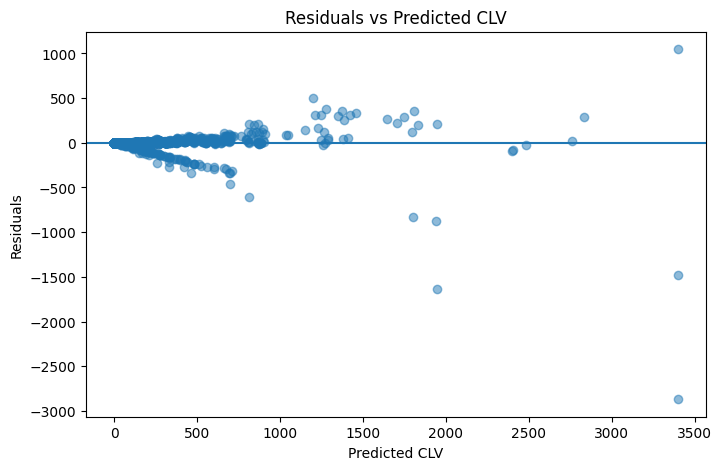

In [55]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8,5))
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(0)
plt.xlabel("Predicted CLV")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted CLV")
plt.show()

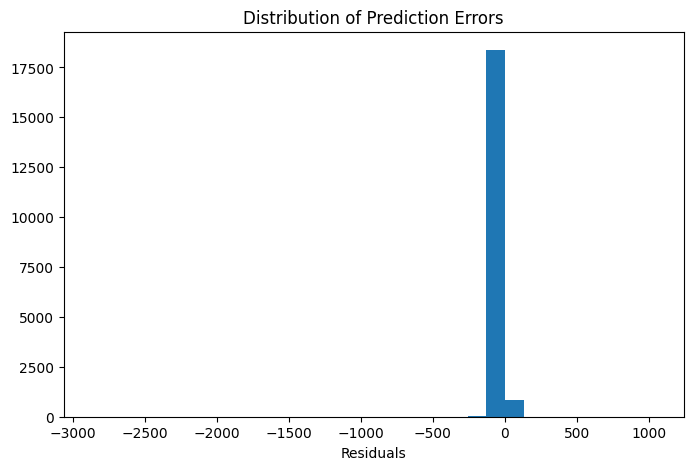

In [56]:
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30)
plt.xlabel("Residuals")
plt.title("Distribution of Prediction Errors")
plt.show()

In [57]:
high_clv_threshold = y_test.quantile(0.9)

high_clv_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_test_pred
})

high_clv_df = high_clv_df[high_clv_df['actual'] >= high_clv_threshold]

high_clv_df.head()

,actual,predicted
66885,1702.35,1198.098441
23286,145.81,142.062207
75873,193.84,190.175532
16990,139.22,138.523547
24134,254.06,254.316185


# Saving Final Model

In [58]:
import joblib 
joblib.dump(model_rf, "clv_random_forest.pkl")

['clv_random_forest.pkl']

In [59]:
model_df.columns

Index(['frequency', 'monetary', 'recency', 'tenure', 'avg_order_value',
       'future_clv'],
      dtype='object')